In [29]:
# 1. Import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import joblib
import json
import os

print("Libraries loaded.")

Libraries loaded.


In [30]:
# 2. Generate synthetic data (diverse distribution)
np.random.seed(2026)
n = 5000

pendapatan = np.random.choice([0,1,2,3], n, p=[0.25, 0.35, 0.25, 0.15])
jumlah_anggota = np.random.choice([1,2,3,4,5], n, p=[0.10, 0.25, 0.30, 0.25, 0.10])
anak_sekolah = np.random.choice([0,1], n, p=[0.45, 0.55])
anak_balita   = np.random.choice([0,1], n, p=[0.65, 0.35])
lansia        = np.random.choice([0,1], n, p=[0.80, 0.20])
disabilitas   = np.random.choice([0,1], n, p=[0.88, 0.12])
dinding_rumah = np.random.choice([0,1,2,3], n, p=[0.35, 0.30, 0.25, 0.10])

df = pd.DataFrame({
    'pendapatan': pendapatan,
    'jumlah_anggota': jumlah_anggota,
    'anak_sekolah': anak_sekolah,
    'anak_balita': anak_balita,
    'lansia': lansia,
    'disabilitas': disabilitas,
    'dinding_rumah': dinding_rumah
})
print("Initial data:", df.shape)

Initial data: (5000, 7)


In [31]:
# 3. Labeling rules (slightly relaxed for inclusivity)
df['PKH'] = ((df['pendapatan'] <= 1) &
             ((df['anak_sekolah']==1) | (df['anak_balita']==1) |
              (df['lansia']==1) | (df['disabilitas']==1))).astype(int)

df['BPNT'] = ((df['pendapatan'] <= 1) &
              (df['jumlah_anggota'] >= 2) &
              (df['dinding_rumah'] >= 1)).astype(int)

df['PIP'] = ((df['pendapatan'] <= 1) &
             (df['anak_sekolah'] == 1)).astype(int)

df['PBI_JKN'] = ((df['pendapatan'] <= 1) &
                 (df['dinding_rumah'] >= 1)).astype(int)

# Keep only rows with at least one benefit
df = df[df[['PKH','BPNT','PIP','PBI_JKN']].sum(axis=1) > 0]
print("After filtering:", df.shape)

After filtering: (2776, 11)


In [32]:
# 4. Add noise to simulate real-world uncertainty
# IMPORTANT: less noise on PKH to avoid creating false positives for high-income
noise_frac = 0.05
rng = np.random.RandomState(42)

for col in ['BPNT','PIP','PBI_JKN']:   # only these labels
    flip_mask = rng.rand(len(df)) < noise_frac
    df.loc[flip_mask, col] = 1 - df.loc[flip_mask, col]

# For PKH, use a much smaller noise (0.5%) to keep its integrity
pk_noise = 0.005
flip_mask_pkh = rng.rand(len(df)) < pk_noise
df.loc[flip_mask_pkh, 'PKH'] = 1 - df.loc[flip_mask_pkh, 'PKH']

# Remove rows that became empty after noise
df = df[df[['PKH','BPNT','PIP','PBI_JKN']].sum(axis=1) > 0]
print("After noise:", df.shape)
print(df[['PKH','BPNT','PIP','PBI_JKN']].mean())

After noise: (2773, 11)
PKH        0.850343
BPNT       0.612333
PIP        0.583484
PBI_JKN    0.669672
dtype: float64


In [33]:
# 5. Add extra negative samples (households that do NOT qualify for any program)
# to balance the training set and reduce false positives
np.random.seed(99)
n_neg = 1500  # additional wealthy/self-sufficient families

neg_pendapatan = np.random.choice([2,3], n_neg, p=[0.4, 0.6])   # mostly high income
neg_anggota = np.random.choice([1,2,3,4,5], n_neg, p=[0.15,0.3,0.3,0.15,0.1])
neg_sekolah = np.random.choice([0,1], n_neg, p=[0.8,0.2])       # rarely school child
neg_balita = np.random.choice([0,1], n_neg, p=[0.9,0.1])
neg_lansia = np.random.choice([0,1], n_neg, p=[0.95,0.05])
neg_disabilitas = np.random.choice([0,1], n_neg, p=[0.98,0.02])
neg_dinding = np.random.choice([0,1], n_neg, p=[0.7,0.3])       # mostly permanent walls

df_neg = pd.DataFrame({
    'pendapatan': neg_pendapatan,
    'jumlah_anggota': neg_anggota,
    'anak_sekolah': neg_sekolah,
    'anak_balita': neg_balita,
    'lansia': neg_lansia,
    'disabilitas': neg_disabilitas,
    'dinding_rumah': neg_dinding
})

# These families receive NO benefits
df_neg['PKH'] = 0
df_neg['BPNT'] = 0
df_neg['PIP'] = 0
df_neg['PBI_JKN'] = 0

# Concatenate with main DataFrame
df = pd.concat([df, df_neg], ignore_index=True)
print("After adding negative samples:", df.shape)
print(df[['PKH','BPNT','PIP','PBI_JKN']].mean())  # should be more balanced

After adding negative samples: (4273, 11)
PKH        0.551837
BPNT       0.397379
PIP        0.378657
PBI_JKN    0.434589
dtype: float64


In [34]:
# 6. Prepare features and labels
X = df[['pendapatan','jumlah_anggota','anak_sekolah','anak_balita',
        'lansia','disabilitas','dinding_rumah']]
y_labels = df[['PKH','BPNT','PIP','PBI_JKN']]

y_list = y_labels.apply(lambda row: [col for col in y_labels.columns if row[col]==1], axis=1)
mlb = MultiLabelBinarizer()
y = mlb.fit_transform(y_list)

print("Classes:", mlb.classes_)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Classes: ['BPNT' 'PBI_JKN' 'PIP' 'PKH']


In [35]:
# 7. Train model (same hyperparameters)
base_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    min_samples_leaf=10,
    random_state=42
)
model = MultiOutputClassifier(base_rf)
model.fit(X_train, y_train)
print("Training completed.")

Training completed.


In [36]:
# 8. Evaluation on test set
y_pred_test = model.predict(X_test)
print("=== Test Set Classification Report ===\n")
for i, prog in enumerate(mlb.classes_):
    print(f"--- {prog} ---")
    print(classification_report(y_test[:,i], y_pred_test[:,i], target_names=['No','Yes']))
    cm = confusion_matrix(y_test[:,i], y_pred_test[:,i])
    print("Confusion matrix:\n", cm, "\n")

=== Test Set Classification Report ===

--- BPNT ---
              precision    recall  f1-score   support

          No       0.99      0.97      0.98       490
         Yes       0.96      0.98      0.97       365

    accuracy                           0.97       855
   macro avg       0.97      0.97      0.97       855
weighted avg       0.97      0.97      0.97       855

Confusion matrix:
 [[474  16]
 [  7 358]] 

--- PBI_JKN ---
              precision    recall  f1-score   support

          No       0.98      0.96      0.97       454
         Yes       0.95      0.98      0.97       401

    accuracy                           0.97       855
   macro avg       0.97      0.97      0.97       855
weighted avg       0.97      0.97      0.97       855

Confusion matrix:
 [[435  19]
 [  8 393]] 

--- PIP ---
              precision    recall  f1-score   support

          No       0.98      0.98      0.98       528
         Yes       0.97      0.98      0.97       327

    accuracy 

In [37]:
# 9. Evaluation on train set (overfitting check)
y_pred_train = model.predict(X_train)
print("=== Train Set Classification Report ===\n")
for i, prog in enumerate(mlb.classes_):
    print(f"--- {prog} ---")
    print(classification_report(y_train[:,i], y_pred_train[:,i], target_names=['No','Yes']))

=== Train Set Classification Report ===

--- BPNT ---
              precision    recall  f1-score   support

          No       0.97      0.97      0.97      2085
         Yes       0.95      0.96      0.95      1333

    accuracy                           0.96      3418
   macro avg       0.96      0.96      0.96      3418
weighted avg       0.96      0.96      0.96      3418

--- PBI_JKN ---
              precision    recall  f1-score   support

          No       0.98      0.96      0.97      1962
         Yes       0.95      0.98      0.96      1456

    accuracy                           0.97      3418
   macro avg       0.97      0.97      0.97      3418
weighted avg       0.97      0.97      0.97      3418

--- PIP ---
              precision    recall  f1-score   support

          No       0.98      0.97      0.97      2127
         Yes       0.95      0.97      0.96      1291

    accuracy                           0.97      3418
   macro avg       0.96      0.97      0.97   

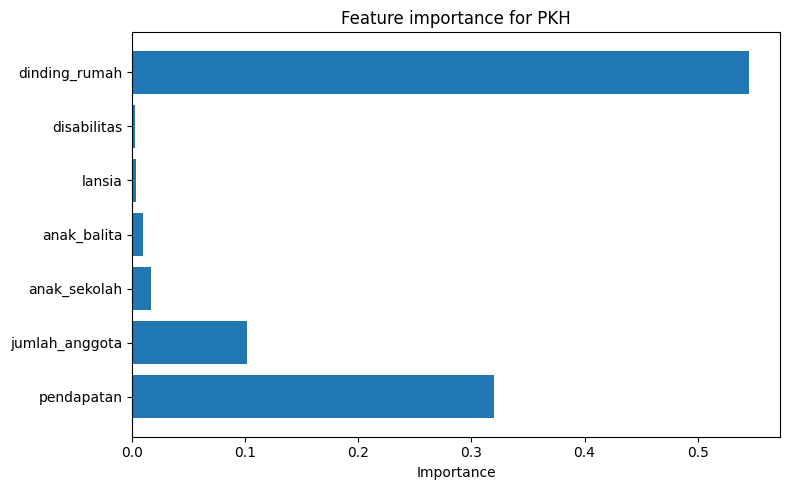

In [38]:
# 10. Feature importance (PKH estimator)
importances = model.estimators_[0].feature_importances_
feature_names = X.columns
plt.figure(figsize=(8,5))
plt.barh(feature_names, importances)
plt.xlabel("Importance")
plt.title("Feature importance for PKH")
plt.tight_layout()
plt.show()

In [39]:
# 11. Save model, encoder, and mapping
os.makedirs('../model', exist_ok=True)
joblib.dump(model, '../model/model.pkl')
joblib.dump(mlb, '../model/encoder.pkl')

mapping = {
    "income_map": {
        "< Rp500.000": 0,
        "Rp500.000 – Rp1.000.000": 1,
        "Rp1.000.000 – Rp2.000.000": 2,
        "> Rp2.000.000": 3
    },
    "anggota_map": {
        "1": 1, "2": 2, "3": 3, "4": 4, "5 atau lebih": 5
    },
    "dinding_map": {
        "Tembok": 0,
        "Semi permanen (setengah tembok)": 1,
        "Papan/kayu": 2,
        "Bambu/lainnya": 3
    },
    "feature_order": [
        "pendapatan", "jumlah_anggota", "anak_sekolah", "anak_balita",
        "lansia", "disabilitas", "dinding_rumah"
    ]
}

with open('../model/mapping.json', 'w') as f:
    json.dump(mapping, f, indent=2)

print("Model, encoder, and mapping.json saved.")

Model, encoder, and mapping.json saved.


In [40]:
# 12. Test case: Ibu Sari (should receive PKH, BPNT, PIP, PBI_JKN)
sample_ibu_sari = pd.DataFrame([[0,4,1,0,0,0,2]], columns=feature_names)
proba_ibu = model.predict_proba(sample_ibu_sari)
print("=== Ibu Sari ===")
for i, prog in enumerate(mlb.classes_):
    print(f"{prog}: {proba_ibu[i][0][1]:.2f}")

=== Ibu Sari ===
BPNT: 0.87
PBI_JKN: 0.89
PIP: 0.90
PKH: 0.93


In [41]:
# 13. Test case: Wealthy family (should receive NOTHING)
sample_kaya = pd.DataFrame([[3,3,0,0,0,0,0]], columns=feature_names)
proba_kaya = model.predict_proba(sample_kaya)
print("=== Wealthy Family ===")
for i, prog in enumerate(mlb.classes_):
    print(f"{prog}: {proba_kaya[i][0][1]:.2f}")

=== Wealthy Family ===
BPNT: 0.01
PBI_JKN: 0.00
PIP: 0.00
PKH: 0.01


In [42]:
# 14. Test case: Poor elderly living alone (should get PKH, PBI_JKN)
sample_lansia = pd.DataFrame([[0,1,0,0,1,0,3]], columns=feature_names)
proba_lansia = model.predict_proba(sample_lansia)
print("=== Poor Elderly ===")
for i, prog in enumerate(mlb.classes_):
    print(f"{prog}: {proba_lansia[i][0][1]:.2f}")

=== Poor Elderly ===
BPNT: 0.33
PBI_JKN: 0.87
PIP: 0.15
PKH: 0.76
